In [1]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

In [5]:


# 1. Load the ARFF file using SciPy
# data, meta = arff.loadarff("C:/Users/USUARIO/Documents/Codigos/Proyecto e-commerce/data/data.arff")
data = pd.read_csv("df_final.csv")

# 2. Convert it into a Pandas DataFrame
df = pd.DataFrame(data)

df.head()

,customer_state,total_payment_value,total_freight,total_weight_g,total_volume_cm3,principal_category_by_price,principal_seller_state_by_price,purchase_year,facturacion_promedio_t1,facturacion_mediana_t1,...,dias_entrega_promedio_7d_avg,dias_entrega_promedio_t2,dias_entrega_promedio_prev_month,es_post_domingo_festivo,es_diciembre,es_fin_de_semana_extendido,distancia_km,distancia_total_t1,distancia_total_prev_month,delivery_days
0,SP,38.71,8.72,500.0,1976.0,b'utilidades_domesticas',SP,2017.0,111.890769,91.660,...,10.860524,10.043478,11.886244,1.0,0.0,0.0,18.576110,4025.883311,291113.407386,8.0
1,SP,32.70,12.80,200.0,2560.0,b'cama_mesa_banho',SP,2018.0,169.101283,112.680,...,7.619223,9.063401,11.552505,0.0,0.0,0.0,309.131371,25226.900324,488209.852444,4.0
2,SP,29.75,11.85,250.0,4800.0,b'cama_mesa_banho',SP,2017.0,170.919272,117.600,...,12.902686,12.000000,11.846389,0.0,0.0,0.0,209.757656,9623.066166,343516.704227,6.0
3,SP,118.86,8.96,525.0,4368.0,b'beleza_saude',SP,2017.0,219.488889,106.805,...,11.561738,10.369565,11.021440,1.0,0.0,0.0,11.680956,6110.978959,304388.330097,21.0
4,SP,88.90,8.91,250.0,3960.0,b'beleza_saude',SP,2018.0,138.861099,100.485,...,15.758284,15.924686,14.586934,0.0,0.0,0.0,13.817425,15249.215838,421109.470293,4.0


In [6]:
#Corregir tipo de datos
df['customer_state']=df['customer_state'].astype('category')
df['principal_category_by_price']=df['principal_category_by_price'].astype('category')
df['principal_seller_state_by_price']=df['principal_seller_state_by_price'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23667 entries, 0 to 23666
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype   
---  ------                            --------------  -----   
 0   customer_state                    23667 non-null  category
 1   total_payment_value               23667 non-null  float64 
 2   total_freight                     23667 non-null  float64 
 3   total_weight_g                    23667 non-null  float64 
 4   total_volume_cm3                  23667 non-null  float64 
 5   principal_category_by_price       23667 non-null  category
 6   principal_seller_state_by_price   23667 non-null  category
 7   purchase_year                     23667 non-null  float64 
 8   facturacion_promedio_t1           23667 non-null  float64 
 9   facturacion_mediana_t1            23667 non-null  float64 
 10  facturacion_std_t1                23667 non-null  float64 
 11  facturacion_total_7d_avg          23667 non-null  floa

In [8]:
df["purchase_year"] = df["purchase_year"].astype(int)
flags = ["es_post_domingo_festivo", "es_diciembre", "es_fin_de_semana_extendido"]
df[flags] = df[flags].astype(int)

cat_cols = ["customer_state", "principal_category_by_price", "principal_seller_state_by_price"]
for col in cat_cols:
    df[col] = (
        df[col].astype(object)
        .map(lambda x: x.decode("utf-8") if isinstance(x, bytes) else x)
        .astype("category")
    )

data = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)
print(data.shape)
print([c for c in data.columns if "b'" in c])  # debe imprimir []
print(data.head())

(23667, 33)
["principal_category_by_price_b'beleza_saude'", "principal_category_by_price_b'brinquedos'", "principal_category_by_price_b'cama_mesa_banho'", "principal_category_by_price_b'esporte_lazer'", "principal_category_by_price_b'informatica_acessorios'", "principal_category_by_price_b'moveis_decoracao'", "principal_category_by_price_b'relogios_presentes'", "principal_category_by_price_b'utilidades_domesticas'"]
   total_payment_value  total_freight  total_weight_g  total_volume_cm3  \
0                38.71           8.72           500.0            1976.0   
1                32.70          12.80           200.0            2560.0   
2                29.75          11.85           250.0            4800.0   
3               118.86           8.96           525.0            4368.0   
4                88.90           8.91           250.0            3960.0   

   purchase_year  facturacion_promedio_t1  facturacion_mediana_t1  \
0           2017               111.890769                  9

In [9]:
#Se separa variables predictoras y objetivo
objetivo = 'delivery_days'
X = data.drop(objetivo, axis=1)
Y = data[objetivo]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23667 entries, 0 to 23666
Data columns (total 32 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   total_payment_value                                    23667 non-null  float64
 1   total_freight                                          23667 non-null  float64
 2   total_weight_g                                         23667 non-null  float64
 3   total_volume_cm3                                       23667 non-null  float64
 4   purchase_year                                          23667 non-null  int64  
 5   facturacion_promedio_t1                                23667 non-null  float64
 6   facturacion_mediana_t1                                 23667 non-null  float64
 7   facturacion_std_t1                                     23667 non-null  float64
 8   facturacion_total_7d_avg                      

In [10]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import cross_validate
from sklearn import tree

# 1. Creas la función
def wmape_func(y_real, y_pred):
    return np.sum(np.abs(y_real - y_pred)) / np.sum(np.abs(y_real))

# 2. La conviertes en un métrica compatible con Scikit-Learn
# Le ponemos greater_is_better=False para que siga la misma lógica negativa de tus otras métricas
wmape_scorer = make_scorer(wmape_func, greater_is_better=False)

# 3. Lo agregas a tu diccionario de métricas
scoring = {
    'neg_mean_absolute_error': 'neg_mean_absolute_error',
    'neg_mean_squared_error': 'neg_mean_squared_error',
    'neg_root_mean_squared_error': 'neg_root_mean_squared_error',
    'neg_wmape': wmape_scorer, # <--- Tu nueva métrica
    # 'neg_mean_absolute_percentage_error':  'neg_mean_absolute_percentage_error'
}

cv = 10


fit_time                              0.081033
score_time                            0.003018
test_neg_mean_absolute_error          3.082908
train_neg_mean_absolute_error         3.065159
test_neg_mean_squared_error          15.918090
train_neg_mean_squared_error         15.733231
test_neg_root_mean_squared_error      3.989322
train_neg_root_mean_squared_error     3.966503
test_neg_wmape                        0.386586
train_neg_wmape                       0.384315
dtype: float64


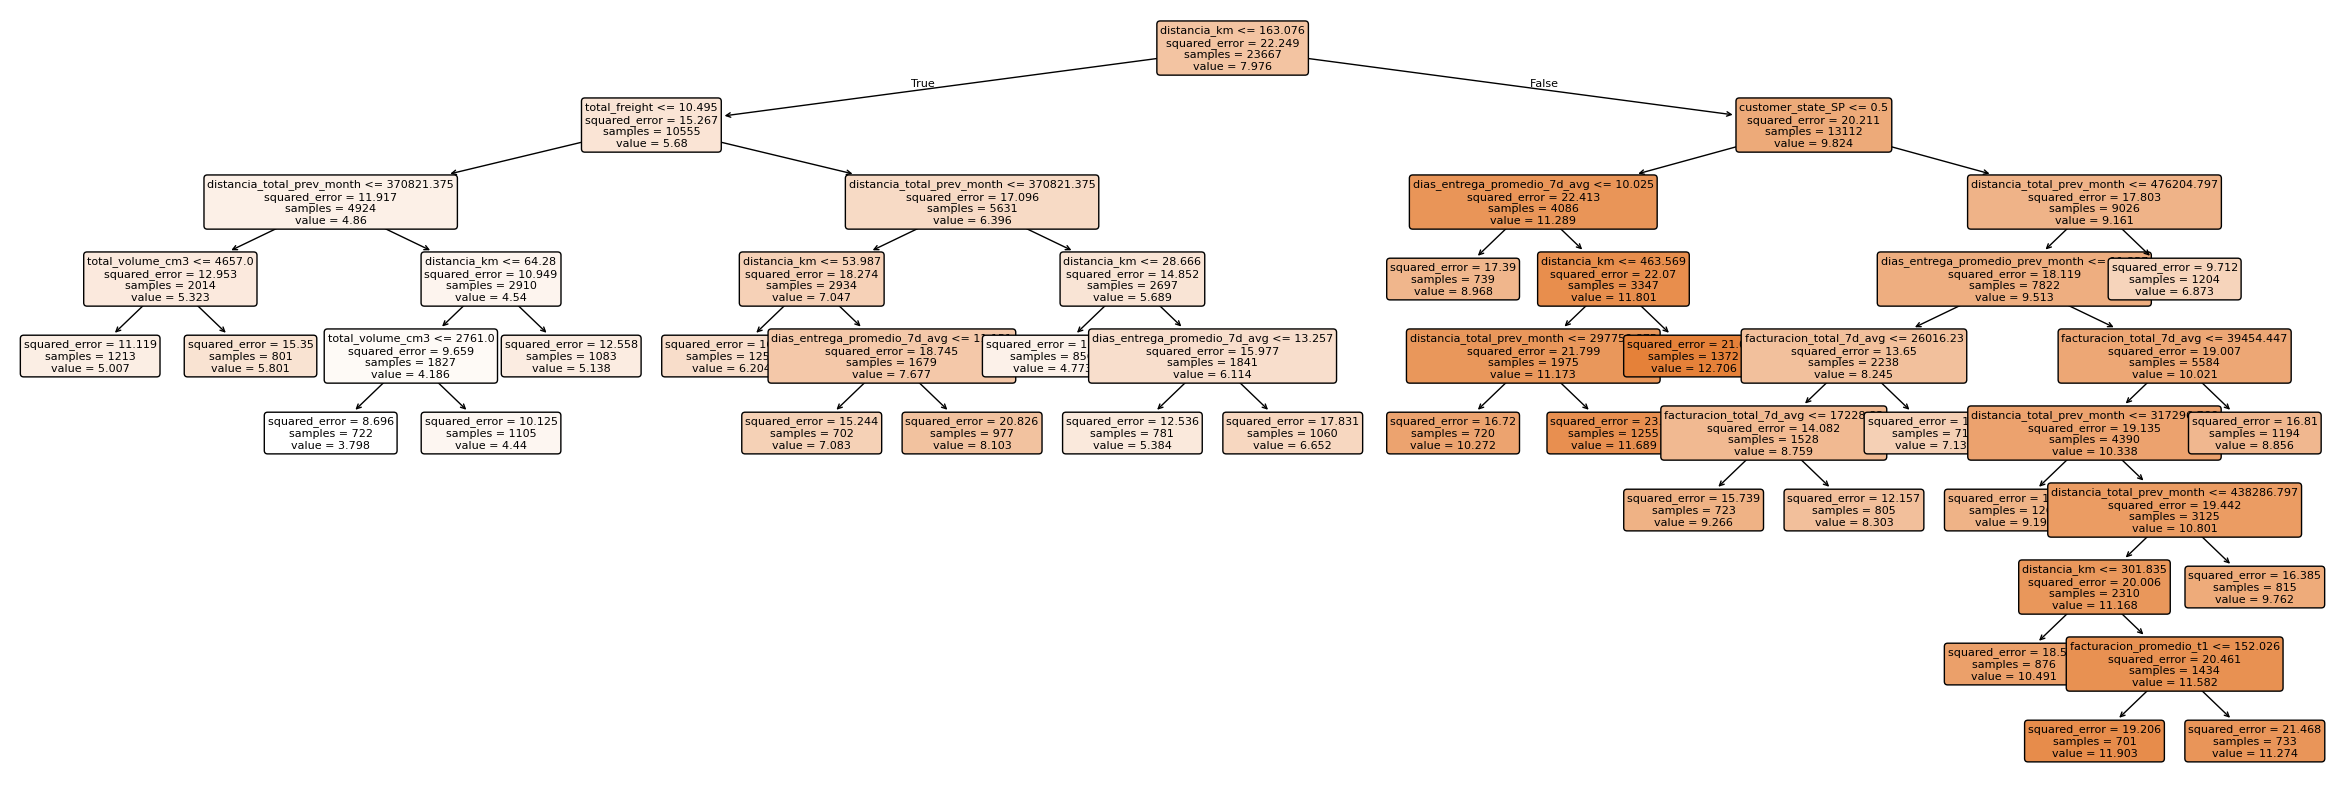

In [12]:
#Tree
from sklearn import tree
from sklearn.model_selection import cross_validate
from sklearn.tree import plot_tree

modelTree = tree.DecisionTreeRegressor(criterion='squared_error', min_samples_leaf=700, max_depth=9, random_state=42)


scores = cross_validate(modelTree, X, Y, cv=cv, scoring=scoring, return_train_score=True, return_estimator=False)
scores=pd.DataFrame(scores) #Se almacenan los resultados en un dataframe
# print(scores)


# 1. Conviertes el diccionario de resultados a un DataFrame
scores_df = pd.DataFrame(scores)

# 2. Ahora sí puedes calcular el promedio
resultados_promedio_dt = scores_df.mean()

# 3. Aplicas el valor absoluto a las métricas de error (a partir de la fila 2)
resultados_promedio_dt[2:] = resultados_promedio_dt[2:].abs()

print(resultados_promedio_dt)

# Entrenamos una instancia para poder visualizarla
modelTree_fit = modelTree.fit(X, Y)

plt.figure(figsize=(30, 10))
plot_tree(modelTree_fit, feature_names=X.columns, filled=True, rounded=True, fontsize=8)
plt.show()

In [13]:
DF_CLISTERING = pd.DataFrame({'feature': X.columns, 'importance': modelTree_fit.feature_importances_})

In [16]:
DF_CLUSTERING = pd.DataFrame({
    'feature': X.columns,
    'importance': modelTree_fit.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

DF_CLUSTERING['importance_acum'] = DF_CLUSTERING['importance'].cumsum()
print(DF_CLUSTERING.head(15))

                             feature  importance  importance_acum
0                       distancia_km    0.682873         0.682873
1         distancia_total_prev_month    0.096628         0.779501
2                  customer_state_SP    0.081872         0.861373
3                      total_freight    0.039846         0.901219
4       dias_entrega_promedio_7d_avg    0.038633         0.939852
5   dias_entrega_promedio_prev_month    0.032418         0.972271
6           facturacion_total_7d_avg    0.023701         0.995972
7                   total_volume_cm3    0.003117         0.999089
8            facturacion_promedio_t1    0.000911         1.000000
9             facturacion_mediana_t1    0.000000         1.000000
10                facturacion_std_t1    0.000000         1.000000
11                    total_weight_g    0.000000         1.000000
12          dias_entrega_promedio_t2    0.000000         1.000000
13           es_post_domingo_festivo    0.000000         1.000000
14        

In [34]:
import re

# Patrones de las variables que NO quieres incluir
patrones_excluir = ['_t1', '7d', 'prev_month', '_t2']   # agrega más aquí (ej. 'prepmont', '30d', etc.)

regex = '|'.join(patrones_excluir)

DF_FILTRADO = DF_CLUSTERING[
    ~DF_CLUSTERING['feature'].str.contains(regex, case=False, regex=True)
].reset_index(drop=True)

# Recalcular el acumulado sobre el subconjunto filtrado
DF_FILTRADO['importance_acum'] = DF_FILTRADO['importance'].cumsum()

top_features = DF_FILTRADO['feature'].head(5).tolist()
print(top_features)


['distancia_km', 'customer_state_SP', 'total_freight', 'total_volume_cm3', 'total_weight_g']


In [26]:
DF_CLUSTERING = DF_CLUSTERING.sort_values('importance', ascending=False).reset_index(drop=True)


In [35]:
import numpy as np
from sklearn.preprocessing import StandardScaler

X_sel = X[top_features].copy()

# Solo a las continuas con sesgo (ajusta los nombres a tus variables)
cols_log = ['distancia_km', 'total_freight', 'total_volume_cm3', 'total_weight_g']
X_sel[cols_log] = np.log1p(X_sel[cols_log])

X_scaled = StandardScaler().fit_transform(X_sel)

In [36]:
print(set(cols_log) - set(top_features))   # debe imprimir set()
print((X_sel[cols_log] < 0).sum())         # debe ser 0 en todas
print(X_sel.isna().sum())                  # KMeans no acepta NaN

set()
distancia_km        0
total_freight       0
total_volume_cm3    0
total_weight_g      0
dtype: int64
distancia_km         0
customer_state_SP    0
total_freight        0
total_volume_cm3     0
total_weight_g       0
dtype: int64


In [37]:
print(X_sel.corr().round(2))
print(X_sel[cols_log].skew().round(2))

                   distancia_km  customer_state_SP  total_freight  \
distancia_km               1.00              -0.34           0.37   
customer_state_SP         -0.34               1.00          -0.21   
total_freight              0.37              -0.21           1.00   
total_volume_cm3           0.04              -0.01           0.48   
total_weight_g             0.06              -0.03           0.54   

                   total_volume_cm3  total_weight_g  
distancia_km                   0.04            0.06  
customer_state_SP             -0.01           -0.03  
total_freight                  0.48            0.54  
total_volume_cm3               1.00            0.74  
total_weight_g                 0.74            1.00  
distancia_km       -0.78
total_freight       0.15
total_volume_cm3    0.01
total_weight_g      0.47
dtype: float64


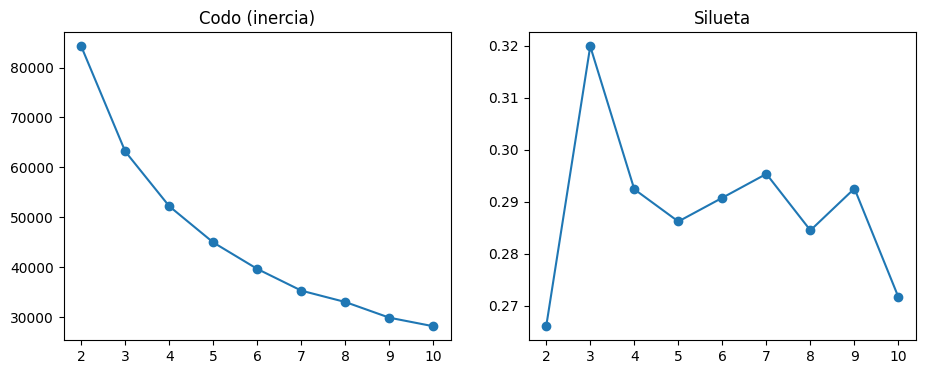

In [38]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cols_modelo = list(X_sel.columns)   # o la lista reducida, ej. ['distancia_km', 'total_weight_g', 'customer_state_SP']
X_scaled = StandardScaler().fit_transform(X_sel[cols_modelo])

ks = range(2, 11)
inercia, silueta = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled)
    inercia.append(km.inertia_)
    silueta.append(silhouette_score(X_scaled, km.labels_, sample_size=10000, random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ks, inercia, marker='o'); ax[0].set_title('Codo (inercia)')
ax[1].plot(ks, silueta, marker='o'); ax[1].set_title('Silueta')
plt.show()

In [40]:
import numpy as np, joblib
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

cols_modelo = ['distancia_km', 'customer_state_SP', 'total_freight',
               'total_volume_cm3', 'total_weight_g']
cols_log = ['distancia_km', 'total_freight', 'total_volume_cm3', 'total_weight_g']

cluster_pipe = Pipeline([
    ('prep', ColumnTransformer([
        ('log', FunctionTransformer(np.log1p), cols_log),
        ('bin', 'passthrough', ['customer_state_SP'])
    ])),
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(n_clusters=3, n_init=10, random_state=42))
])

labels = cluster_pipe.fit_predict(X[cols_modelo])

# Verifica que el perfil coincide con el anterior (los números de cluster pueden cambiar)
chk = X[cols_modelo].copy(); chk['cluster'] = labels
print(chk.groupby('cluster').median().round(2))
print(chk['cluster'].value_counts(normalize=True).round(3))

joblib.dump(cluster_pipe, 'cluster_pipe.joblib')

         distancia_km  customer_state_SP  total_freight  total_volume_cm3  \
cluster                                                                     
0              379.18                0.0          17.74            8000.0   
1              104.79                1.0          11.74            3500.0   
2              223.58                1.0          16.49           20000.0   

         total_weight_g  
cluster                  
0                 900.0  
1                 350.0  
2                2100.0  
cluster
1    0.454
2    0.360
0    0.185
Name: proportion, dtype: float64


['cluster_pipe.joblib']

In [41]:
import pickle

# 1. Ajustar el pipeline (si no lo has hecho ya)
labels = cluster_pipe.fit_predict(X[cols_modelo])

# 2. Revisar el perfil ANTES de nombrar los clusters (los números pueden cambiar al reajustar)
chk = X[cols_modelo].copy()
chk['cluster'] = labels
print(chk.groupby('cluster').median().round(2))
print(chk['cluster'].value_counts(normalize=True).round(3))

         distancia_km  customer_state_SP  total_freight  total_volume_cm3  \
cluster                                                                     
0              379.18                0.0          17.74            8000.0   
1              104.79                1.0          11.74            3500.0   
2              223.58                1.0          16.49           20000.0   

         total_weight_g  
cluster                  
0                 900.0  
1                 350.0  
2                2100.0  
cluster
1    0.454
2    0.360
0    0.185
Name: proportion, dtype: float64


In [44]:
NOMBRES = {
    0: 'Larga distancia',
    1: 'Local y ligero',
    2: 'Voluminoso y pesado',
}

# 3. Guardar todo en un solo archivo
artefacto = {
    'pipeline': cluster_pipe,
    'columnas': cols_modelo,      # orden y nombres que espera el modelo
    'nombres_clusters': NOMBRES,
}

with open('cluster_pipe.pkl', 'wb') as f:
    pickle.dump(artefacto, f)

In [ ]:
with open('cluster_pipe.pkl', 'rb') as f:
    art = pickle.load(f)

prueba = pd.DataFrame([{
    'distancia_km': 286.22,
    'customer_state_SP': 0,
    'total_freight': 20.0,
    'total_volume_cm3': 352.0,
    'total_weight_g': 50.0,
}])[art['columnas']]

c = int(art['pipeline'].predict(prueba)[0])
print(c, art['nombres_clusters'][c])

0 Larga distancia


: 